# ✨Evaluating spectral reflectance separability✨

This notebook can be used to evaluate spectral separability of point-source spectra using three methods: Hierarchical Cluster Analysis, Spectral Angle Classification, and Random Forest Classification.

## 🔨 Set-up 
Importing modules and data

In [157]:
# Import required scripts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import speca.label_data as sld
import speca.plot_data as spd
import speca.resampling as srs
import pvclust
import speca.preprocessing as prep
import speca.visualizing as sv
import speca.auxiliary as aux
import speca.spectral_angle_method as sam
import speca.random_forest as rfc
import speca.pca_decomposition as pca

In [3]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

##  🏭 Preprocessing

This section runs the Preprocessor class which imports the data labelled by class name, cleans the data, and filters to desired classes. If a scaler is chosen, it will scale the data accordingly.

In [4]:
# Define preprocessing parameters
path = r"C:\Users\s4770224\Documents\coding\Spectral_analysis\Combined_analysis\MEL_NZ_TAS_spectra.csv"
bad_bands_list = list(map(str,(range(753, 769))))
scaler = "standard"
target_scheme = "all_macros"
target_sites = None
target_setup = None
start_nm = 460
end_nm = 925

In [5]:
#Run the preprocessing chain
prepper = prep.PreprocessRefl(data_path = path,
                              bad_bands = bad_bands_list,
                              scaler = scaler,
                              target_scheme = target_scheme,
                              target_setup = target_setup,
                              target_sites= target_sites,
                              start_nm = start_nm,
                              end_nm = end_nm)
prepper.default_chain()
spectra_prepped = prepper.spectra_norm
labels_prepped = prepper.labels_filtered

Data filtered from 388 to 333 spectra.


## 📈 Visualise

This section runs the plotting class using the already defined parameters from preprocessing. Spectra to plot are defined by the user by target types and collection site.

In [171]:
# Initialize visualizer with existing parameters
vizer = sv.Visualizer(spectra_prepped, 
                      labels_prepped, 
                      start_nm, 
                      end_nm)

# Calculate class statistics for plotting
vizer.class_stats(grouping="Class", 
                  plot_by_site = True)

### Chose spectra to plot

Search words below defines what target types you want to plot. Search sites is optional, but will let you chose to plot spectra from only the specified site(s). The mode parameter can be `any` or `all` to indicate if all of the search terms need to be met or if all must be found to be returned.

In [172]:
# Define search terms
search_words = ['acrocarpia', 'carpophyllum', 'cystophora', 'durvillaea', 'ecklonia','filamentous_rhodophyte', 'frondose_rhodophyte', 'hormosira',
       'macrocystis', 'phyllospora', 'sargassum', 'scytosiphon', 'ulva', 'petalonia', 'undaria']
search_sites = []
mode = any

In [ ]:
# Run the plotter
vizer.plot_search_terms(search_words= search_words, mode = any, search_sites = search_sites)

##  🔺Hierarchical Cluster Analysis 🔺
This section uses the pvclust adaptation for Python to run an HCA on the prepared spectra. An optional class means dataset is also calculated for clustering means. 

In [97]:
# Calculate class means for clustering
class_means = aux.calc_class_averages(spectra_prepped,
                                      labels_prepped,
                                      label_col="Class")

In [ ]:
# Chose data to cluster
clust_data = class_means

# Perform clustering
pv = pvclust.PvClust(clust_data.T, method = "ward", metric = "euclidean", nboot = 10000, parallel = True)

In [ ]:
# Plot dendrogram
pv.plot(labels= clust_data.index.to_list())

In [ ]:
# Plot clustering standard errors
pv.seplot(pvalue= "AU", annotate=True)

## 📐 Spectral Angle Method
This section runs an adaptation of the conventional spectral angle mapper to be applied to point-source reflectance data.

In [148]:
# strat an instance fo the SAM class
sam = sam.SAM(spectra_prepped, labels_prepped, "Class")

 The accuracy of Class_SAM is: 0.4114114114114114
 The balanced accuracy of Class_SAM is: 0.5360835243188184
 The recall of Class_SAM is: 0.4114114114114114
 The precision of Class_SAM is: 0.4046309284005306


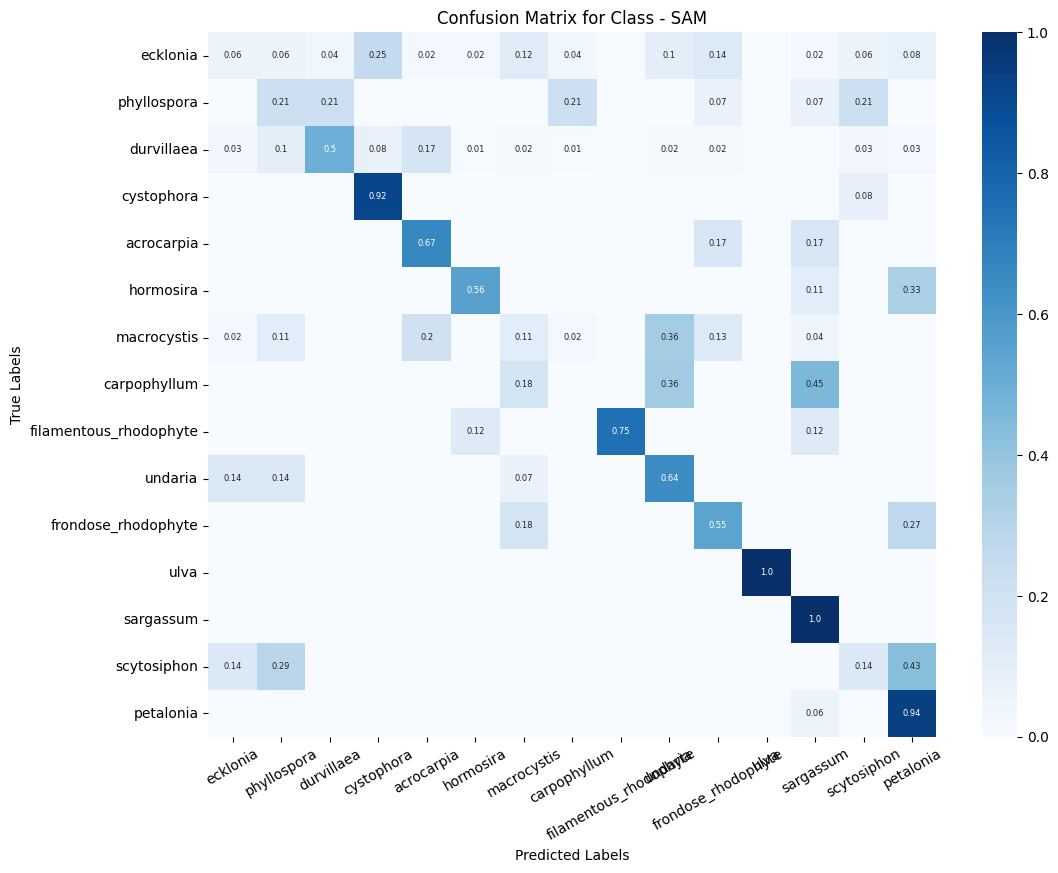

In [154]:
# Run the chain module to perform all SAM steps
sam.sam_chain()

## 🌲🌳 Random Forest 🌳🌲

This section implements a random forest classifier on the spectra. It includes:
- PCA decomposition
- N-comps determination for PCA
- Hyperparameter grid search
- Random Forest classification

In [171]:
# Choose number of components to input to random forest

# Trying elbow and kaiser methods first
components, ev_ratio, ev = pca.run_pca(spectra_prepped, n_comps=20)

elbow = pca.find_elbow(ev_ratio)
print(f"Elbow found at: {elbow} components \n  Explained variance ratio: {ev_ratio[elbow]} \n  Total explained variance: {np.sum(ev_ratio[:elbow+1])}")

kaiser = pca.find_kaiser(ev)
print(f"Kaiser value found at: {kaiser} components \n  Explained variance ratio: {ev_ratio[kaiser]} \n  Total explained variance: {np.sum(ev_ratio[:kaiser+1])}")

Elbow found at: 3 components 
  Explained variance ratio: 0.028824416771378928 
  Total explained variance: 0.9237828498048055
Kaiser value found at: 2 components 
  Explained variance ratio: 0.055245003596960454 
  Total explained variance: 0.8949584330334266


In [192]:
# Trying accuracy-based methods
accub = pca.NCompsByAccuracy(components, labels_prepped, labels_col = "Class")
accub.calc_mean_accuracies(max_n = 20)


{'n': 7, 'Accuracy at n': 0.8165, 'Max Accuracy': 0.8627999999999999} {'n': 3, 'Accuracy at n': 0.7113, 'Accuracy at n+1': 0.7488000000000002}


In [194]:
proximity = accub.find_n_by_max_proximity()
margin = accub.find_n_by_margin()
print(proximity)
print(margin)

{'n': 7, 'Accuracy at n': 0.8165, 'Max Accuracy': 0.8627999999999999}
{'n': 3, 'Accuracy at n': 0.7113, 'Accuracy at n+1': 0.7488000000000002}


You now have four options of determining the number of components to keep for subsequent analysis. Two based on dataset variance, and two based on preliminary classification accuracy. The best suited option is subjective and will affect data volume, computational requirements, processing time, and accuracy.

# 🔮 Testing